## Classify + regression

##

In [1]:
# loading packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as ss

In [2]:
# machine learning regression
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_validate
from sklearn.preprocessing import PolynomialFeatures , MinMaxScaler
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, RidgeCV, Lasso, LassoCV, ElasticNet, BayesianRidge 
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score  , mean_absolute_percentage_error
from sklearn.preprocessing import scale
from sklearn.decomposition import PCA
from sklearn.utils import shuffle
from sklearn.cluster import KMeans


from xgboost import XGBRegressor

In [3]:
# Machine Leraning Classify
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import GridSearchCV

In [4]:
df_original = pd.read_csv("C:\\Github\\Coral_Bleaching_Predictor\\Data\\dataset.csv" , na_values=['nd']) # old data
df_original

,ID,Latitude_Degrees,Longitude_Degrees,Ocean,Realm,Ecoregion,Country_Name,State_Island_Province,City_Town,City_Town_2,...,TSA_Maximum,TSA_Mean,TSA_Frequency,TSA_Frequency_Standard_Deviation,TSA_FrequencyMax,TSA_FrequencyMean,TSA_DHW,TSA_DHW_Standard_Deviation,TSA_DHWMax,TSA_DHWMean
0,97,-20.899833,149.407722,Pacific,Central Indo-Pacific,Southern Great Barrier Reef,Australia,Queensland,Keswick Island,NaN,...,2.40,-3.26,3.0,1.95,7.0,1.0,3.52,1.36,8.43,0.52
1,98,-20.893056,149.421000,Pacific,Central Indo-Pacific,Southern Great Barrier Reef,Australia,Queensland,Keswick Island,NaN,...,2.40,-3.26,3.0,1.95,7.0,1.0,3.52,1.36,8.43,0.52
2,116,-20.745806,149.472056,Pacific,Central Indo-Pacific,Southern Great Barrier Reef,Australia,Queensland,Wigton Island,Wigton Island Reef,...,2.34,-3.06,1.0,1.47,5.0,1.0,1.51,1.23,7.32,0.49
3,117,-20.737694,149.464944,Pacific,Central Indo-Pacific,Southern Great Barrier Reef,Australia,Queensland,Wigton Island,Wigton Island Reef,...,2.64,-3.01,2.0,1.31,5.0,1.0,2.36,0.97,6.86,0.36
4,142,-20.259361,148.814583,Pacific,Central Indo-Pacific,Central and northern Great Barrier Reef,Australia,Queensland,Mount Rooper,Daydream Island,...,2.81,-3.23,4.0,1.72,7.0,1.0,0.00,1.47,9.84,0.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9660,13073,13.935889,48.386417,Red Sea,Western Indo-Pacific,Gulf of Aden,Yemen,Shabwah Governorate,Bi'r Ali,Eemad,...,10.59,-1.86,1.0,2.30,11.0,2.0,2.63,2.57,20.95,1.08
9661,13074,13.935889,48.386417,Red Sea,Western Indo-Pacific,Gulf of Aden,Yemen,Shabwah Governorate,Bi'r Ali,Eemad,...,10.59,-1.86,1.0,2.30,11.0,2.0,2.63,2.57,20.95,1.08
9662,13075,14.817722,50.015250,Red Sea,Western Indo-Pacific,Gulf of Aden,Yemen,Hadhramaut Governorate,Al-Qurn,Eemad,...,10.51,-2.13,0.0,1.97,10.0,2.0,0.00,2.74,23.70,1.09
9663,13076,15.701611,42.391806,Red Sea,Western Indo-Pacific,South Red Sea,Yemen,Al Hudaydah Governorate,Jazirat Antufash,Seaem,...,2.52,-2.69,0.0,1.63,6.0,1.0,0.00,1.33,8.30,0.54


In [5]:
print(f"total number of rows and columns in the dataset: {len(df_original.columns)} columns, {len(df_original)} rows")

total number of rows and columns in the dataset: 48 columns, 9665 rows


In [6]:
## Grouping years into decodes
def Cleaning_date_to_year(df):
    #Changing date to year
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df['Year'] = df['Date'].dt.year # New columns with only year 
    
    year_counts = df.groupby(['Year']).size()
    print(year_counts)
    

    return df

df_Makedatetime = Cleaning_date_to_year(df_original)

Year
1998      5
2000      2
2001      3
2002     63
2003    599
2004    731
2005    700
2006    850
2007    643
2008    692
2009    721
2010    538
2011    533
2012    563
2013    626
2014    600
2015    615
2016    619
2017    562
dtype: int64


In [7]:
#Check NAN Data and by what percentage
def nan_check(data):
    total = data.isnull().sum().sort_values(ascending=False)
    percent_1 = data.isnull().sum()/data.isnull().count()*100
    percent_2 = (np.round(percent_1, 1)).sort_values(ascending=False)
    missing_data = pd.concat([total, percent_2], axis=1, keys=['Total', '%'])
    return missing_data

Missing  = nan_check(df_Makedatetime)

In [8]:
def Columns_percent_missing(df,df_dtype, col):
    
    count_less = 0
    count_more = 0
    Index_more = []
    Index_less = []
    for_drop = []
    type_object = []
    type_number = []
    for idx, value in df[col].items():
        if value >= 0.4:
            count_more += 1
            Index_more.append(idx)
            for_drop.append(idx)
        elif value < 0.4:
            count_less += 1
            Index_less.append(idx)
            
    for i in df_dtype.columns:
        if df_dtype[i].dtype == 'object':
            type_object.append(i)
        else:
            type_number.append(i)

    print("\n")
    print(f"more than 0.4% : {count_more}")
    print(f"less than 0.4% : {count_less}")
    print(f"Index_more : {len(Index_more)} attribuue : {Index_more}")
    print(f"Index_less : {len(Index_less)} attribuue : {Index_less}")
    print(f"for_drop : {len(for_drop)} attribuue : {for_drop}")
    print(f"object type : {len(type_object)} attribue : {type_object}")
    print(f"number type : {len(type_number)} attribue : {type_number}")

    return for_drop , type_object
    
columns_drop, col_object = Columns_percent_missing(Missing, df_original, '%')
print("Missing values more than 0.4% : Delete")



more than 0.4% : 4
less than 0.4% : 45
Index_more : 4 attribuue : ['City_Town_3', 'City_Town_2', 'City_Town', 'State_Island_Province']
Index_less : 45 attribuue : ['SSTA_Minimum', 'SSTA_FrequencyMax', 'SSTA_Standard_Deviation', 'TSA_Maximum', 'SSTA_Maximum', 'SSTA_Frequency', 'SSTA_Frequency_Standard_Deviation', 'SSTA_Mean', 'SSTA_FrequencyMean', 'Temperature_Kelvin_Standard_Deviation', 'SSTA_DHW', 'SSTA_DHW_Standard_Deviation', 'SSTA_DHWMax', 'SSTA_DHWMean', 'TSA', 'SSTA', 'Temperature_Minimum', 'Temperature_Maximum', 'TSA_Minimum', 'Temperature_Mean', 'Temperature_Kelvin', 'TSA_Mean', 'TSA_Frequency', 'TSA_Frequency_Standard_Deviation', 'TSA_FrequencyMax', 'TSA_FrequencyMean', 'TSA_DHW', 'TSA_DHW_Standard_Deviation', 'TSA_DHWMax', 'TSA_DHWMean', 'TSA_Standard_Deviation', 'Windspeed', 'ClimSST', 'ID', 'Latitude_Degrees', 'Average_Bleaching', 'Depth', 'Date2', 'Date', 'Country_Name', 'Ecoregion', 'Realm', 'Ocean', 'Longitude_Degrees', 'Year']
for_drop : 4 attribuue : ['City_Town_3', 

In [9]:
def Clean_data_paper(df, col_object, col_dont_need):
    
    # using data from 2003 to 2020
    df = df[df['Year'] > 2002]

    # Taking only SSTA > 0
    df['SSTA'] = pd.to_numeric(df['SSTA'], errors='coerce') # แปลง ค่าของ SSTA เป็นตัวเลข เเละจัดการกับค่าที่ไม่สามารถเเปลงได้ด้วยการใช้ 'coerce' ซึ่งจะทำให้ค่าที่แปลงไม่ได้กลายเป็น NaN
    df = df[df['SSTA'] > 0] # เลือกเฉพาะคที่มีค่า SSTA มากกว่า 0 เเละ NaN จะถูกละทิ้งไปโดยอัตโนมัติ
    
    df_object = df.drop(columns=col_object) # ลบคอลัมน์ที่เป็น Object ออกเเละค่าที่ไม่จำเป็นออกไป
    df_dont_need = df_object.drop(columns=col_dont_need) # ลบคอลัมน์ที่ไม่จำเป็นออกไป

    df = df_dont_need.rename(columns={"Depth": "Depth_m", "Average_Bleaching": "Percent_Bleaching"}) # เปลี่ยนชื่อคอลัมน์ให้สั้นลง เเละเจข้าใจง่ายขึ้น

    #Transforming column datatypes
    df['ClimSST'] = pd.to_numeric(df['ClimSST'],errors='coerce')
    df['Percent_Bleaching'] = pd.to_numeric(df['Percent_Bleaching'],errors='coerce')
    
    return df

col_dont_need = ['ID', 'Date', 'Date2', 'Year' , 'SSTA_Mean']
df_Clean_already = Clean_data_paper(df_Makedatetime, col_object, col_dont_need)
df_Clean_already = df_Clean_already.fillna(method='ffill')

print(f"total number of rows and columns in the dataset: {len(df_Clean_already.columns)} columns, {len(df_Clean_already)} rows")
print("มีการเพิ่มคอลัมน์ Year ขึ้นมาเพื่อนำมาใช้ในการจัดกลุ่มข้อมูลตามปี")

total number of rows and columns in the dataset: 36 columns, 6112 rows
มีการเพิ่มคอลัมน์ Year ขึ้นมาเพื่อนำมาใช้ในการจัดกลุ่มข้อมูลตามปี


C:\Users\superuser\AppData\Local\Temp\ipykernel_14196\3032694163.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['SSTA'] = pd.to_numeric(df['SSTA'], errors='coerce') # แปลง ค่าของ SSTA เป็นตัวเลข เเละจัดการกับค่าที่ไม่สามารถเเปลงได้ด้วยการใช้ 'coerce' ซึ่งจะทำให้ค่าที่แปลงไม่ได้กลายเป็น NaN
C:\Users\superuser\AppData\Local\Temp\ipykernel_14196\3032694163.py:23: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_Clean_already = df_Clean_already.fillna(method='ffill')


##

### งานเเรกคือการทำ Classify โดยใช้ feature ตาม paper

In [10]:
df_Classify_model = df_Clean_already.copy()

In [11]:
# 1. สร้างคอลัมน์ 'Bin' เพื่อช่วยในการแบ่ง (Stratification)
# แบ่งเป็น 0 (ไม่ฟอก) กับ 1 (ฟอกขาว)
df_Classify_model['Classify'] = (df_Classify_model['Percent_Bleaching'] > 0).astype(int)
print(df_Classify_model[['Classify']].value_counts())
print('='*40)
print(f"Original feature : {len(df_Clean_already.columns)} ---> become {len(df_Classify_model.columns)}")

Classify
0           3914
1           2198
Name: count, dtype: int64
Original feature : 36 ---> become 37


In [12]:
df_paperwraning = ['SSTA', 'Depth_m', 'ClimSST', 'Latitude_Degrees', 'Longitude_Degrees' , 'Windspeed' , 'SSTA_DHW']
feature_Classify = df_Classify_model[df_paperwraning].values
target_Classify = df_Classify_model['Classify'].values



In [13]:
feature_Classify

array([[1.32000000e+00, 4.00000000e+00, 2.97780000e+02, ...,
        1.49407722e+02, 5.00000000e+00, 3.96000000e+00],
       [1.32000000e+00, 5.00000000e+00, 2.97780000e+02, ...,
        1.49421000e+02, 5.00000000e+00, 3.96000000e+00],
       [8.70000000e-01, 6.00000000e+00, 2.98170000e+02, ...,
        1.49472056e+02, 5.00000000e+00, 2.68000000e+00],
       ...,
       [5.00000000e-02, 6.00000000e+00, 3.01400000e+02, ...,
        5.38173056e+01, 4.00000000e+00, 0.00000000e+00],
       [1.10000000e-01, 9.00000000e+00, 3.04390000e+02, ...,
        4.23918056e+01, 6.00000000e+00, 2.25000000e+00],
       [1.10000000e-01, 5.00000000e+00, 3.04390000e+02, ...,
        4.23918056e+01, 6.00000000e+00, 2.25000000e+00]])

In [14]:
target_Classify

array([1, 1, 1, ..., 0, 0, 0])

In [15]:
def set_datapretrain(X,y):
    X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)
    
    return X_train_class, X_test_class, y_train_class , y_test_class

X_train_classpaper , X_test_classpaper , y_train_classpaper , y_test_classpaper = set_datapretrain(feature_Classify,target_Classify)


def training_model(X_train, y_train, X_test, y_test):
    rf_class = RandomForestClassifier(n_estimators=200, max_features=None,max_depth=None,min_samples_split=2,min_samples_leaf=2,class_weight="balanced_subsample", random_state=42)

    rf_class.fit(X_train, y_train)

    # Before (threshold = 0.50)
    y_pred_default = rf_class.predict(X_test)

    # After (threshold = 0.45)
    y_prob = rf_class.predict_proba(X_test)[:, 1]
    y_pred_adjusted = (y_prob >= 0.40).astype(int)

    print("=== Before (Threshold = 0.50) ===")
    print(classification_report(y_test, y_pred_default))

    print("=== After (Threshold = 0.45) ===")
    print(classification_report(y_test, y_pred_adjusted))

    print("AUC:", roc_auc_score(y_test, y_prob))  # AUC ไม่เปลี่ยน
    
    return rf_class, y_pred_adjusted
    
rf_class, y_pred_class = training_model(X_train_classpaper, y_train_classpaper, X_test_classpaper, y_test_classpaper)

=== Before (Threshold = 0.50) ===
              precision    recall  f1-score   support

           0       0.81      0.83      0.82       783
           1       0.68      0.66      0.67       440

    accuracy                           0.77      1223
   macro avg       0.75      0.74      0.75      1223
weighted avg       0.77      0.77      0.77      1223

=== After (Threshold = 0.45) ===
              precision    recall  f1-score   support

           0       0.85      0.74      0.79       783
           1       0.62      0.77      0.69       440

    accuracy                           0.75      1223
   macro avg       0.74      0.75      0.74      1223
weighted avg       0.77      0.75      0.75      1223

AUC: 0.8304699291768258


ALL train data : 1223
y_test_Classify
0                  783
1                  440
Name: count, dtype: int64


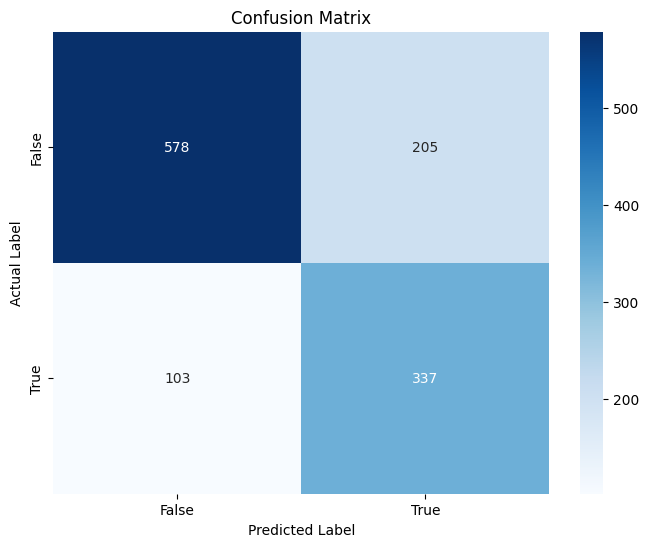

In [16]:
def plot_confusion_matrix(y_true, y_pred, classes):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes)
    plt.title('Confusion Matrix')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()
    
    return cm
    
print(f"ALL train data : {len(y_test_classpaper)}")
print(f"{pd.DataFrame(y_test_classpaper, columns=['y_test_Classify']).value_counts()}")
corr_matrix = plot_confusion_matrix(y_test_classpaper, y_pred_class, ['False','True'])

<Axes: >

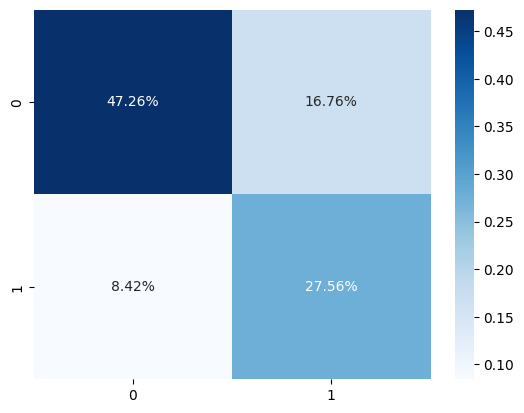

In [17]:
sns.heatmap(corr_matrix/np.sum(corr_matrix), annot=True, 
            fmt='.2%', cmap='Blues')

In [18]:
def feature_importance(model, feature_train):
    importances = model.feature_importances_
    feature_names = feature_train.columns
   
    df_importance = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    }).sort_values(by='importance', ascending=False)
    print(f"Columns have all : {len(df_importance)}")
    
    return df_importance.round(2)

In [19]:
feature_importance(rf_class,df_Classify_model[df_paperwraning])

Columns have all : 7


,feature,importance
3,Latitude_Degrees,0.24
4,Longitude_Degrees,0.23
0,SSTA,0.13
2,ClimSST,0.12
6,SSTA_DHW,0.12
1,Depth_m,0.11
5,Windspeed,0.06


In [20]:
baseline_correlation = (
    df_Classify_model[df_Clean_already.columns.tolist() + ['Classify']]
    .corr()['Classify']
    .sort_values(ascending=False)
    .drop('Classify')
)
baseline_correlation

Percent_Bleaching                        0.387201
Windspeed                                0.106085
TSA_DHW                                  0.090718
SSTA_DHW                                 0.076497
ClimSST                                  0.075151
Depth_m                                  0.066873
SSTA_Minimum                             0.065540
TSA_Frequency                            0.044328
TSA_Minimum                              0.035255
TSA_Maximum                              0.027894
SSTA                                     0.027004
SSTA_Frequency                           0.018281
TSA_DHWMean                              0.017568
TSA                                      0.014456
Temperature_Minimum                      0.014393
TSA_DHW_Standard_Deviation               0.010546
TSA_Mean                                 0.009870
TSA_FrequencyMean                       -0.001847
TSA_DHWMax                              -0.002858
Temperature_Kelvin                      -0.010629


##

### การทดลองด้ววใช้ตัวแปรทั้งหมดเพื่อคัดเลือกตัวแปรที่เหมาะสมมาทำการ Classify

In [21]:
feature_ALL_classify = df_Classify_model.drop(columns=['Percent_Bleaching', 'Classify'])
target_ALL_classify = df_Classify_model['Classify']

feature_ALL_classify_values = feature_ALL_classify.values
target_ALL_classify_values = target_ALL_classify.values

print(f"feature ALL : {len(df_Classify_model.drop(columns=['Percent_Bleaching', 'Classify']).columns)} , dataset : {len(target_ALL_classify)}")

feature ALL : 35 , dataset : 6112


In [22]:
X_train_classALL , X_test_classALL , y_train_classALL , y_test_classALL = set_datapretrain(feature_ALL_classify_values,target_ALL_classify_values)

In [23]:
rf_classALL, y_pred_classALL = training_model(X_train_classALL, y_train_classALL, X_test_classALL, y_test_classALL)

=== Before (Threshold = 0.50) ===
              precision    recall  f1-score   support

           0       0.82      0.84      0.83       783
           1       0.70      0.68      0.69       440

    accuracy                           0.78      1223
   macro avg       0.76      0.76      0.76      1223
weighted avg       0.78      0.78      0.78      1223

=== After (Threshold = 0.45) ===
              precision    recall  f1-score   support

           0       0.85      0.76      0.80       783
           1       0.64      0.76      0.70       440

    accuracy                           0.76      1223
   macro avg       0.75      0.76      0.75      1223
weighted avg       0.77      0.76      0.76      1223

AUC: 0.8478738534773018


ALL train data : 1223
y_test_Classify
0                  783
1                  440
Name: count, dtype: int64


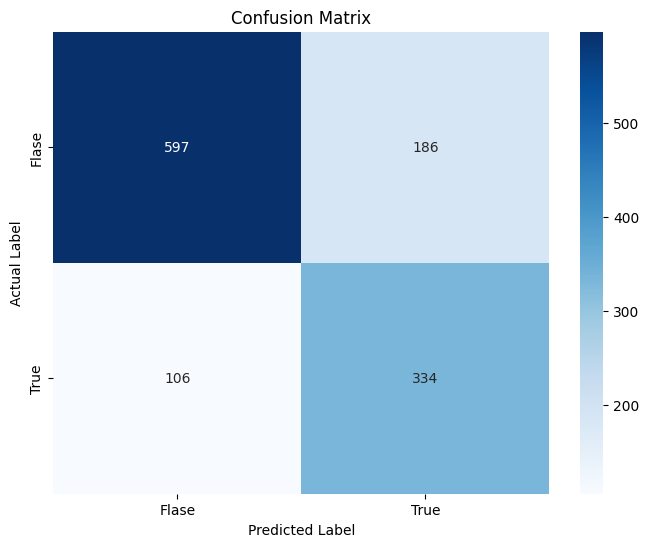

In [24]:
print(f"ALL train data : {len(y_test_classALL)}")
print(f"{pd.DataFrame(y_test_classALL, columns=['y_test_Classify']).value_counts()}")
corr_matrix = plot_confusion_matrix(y_test_classALL, y_pred_classALL, ['Flase','True'])

In [25]:
feature_importance(rf_classALL,feature_ALL_classify)

Columns have all : 35


,feature,importance
0,Latitude_Degrees,0.10
1,Longitude_Degrees,0.07
2,Depth_m,0.06
5,Temperature_Mean,0.05
10,SSTA,0.05
4,Temperature_Kelvin,0.05
3,ClimSST,0.05
18,SSTA_DHW,0.05
14,SSTA_Frequency,0.04
22,TSA,0.04


##

##

### การทำ SMOTE  DATA

In [26]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_classALL, y_train_classALL)

# แก้ตรงนี้ — ใช้ pd.Series() ครอบทั้งคู่
print(f"Before SMOTE: {pd.Series(y_train_classALL).value_counts().to_dict()}")
print(f"After SMOTE : {pd.Series(y_train_res).value_counts().to_dict()}")

# Train โมเดลใหม่บน SMOTE data
rf_smote = rf_classALL
rf_smote.fit(X_train_res, y_train_res)

# วัดผล (threshold = 0.50 ปกติ)
y_pred_smote = rf_smote.predict(X_test_classALL)
print(classification_report(y_test_classALL, y_pred_smote))
print("AUC:", roc_auc_score(y_test_classALL, rf_smote.predict_proba(X_test_classALL)[:,1]))

Before SMOTE: {0: 3131, 1: 1758}
After SMOTE : {0: 3131, 1: 3131}
              precision    recall  f1-score   support

           0       0.83      0.83      0.83       783
           1       0.70      0.70      0.70       440

    accuracy                           0.78      1223
   macro avg       0.76      0.77      0.77      1223
weighted avg       0.78      0.78      0.78      1223

AUC: 0.8490334378265413


In [27]:
rf_smote, y_pred_smote = training_model(X_train_res, y_train_res, X_test_classALL, y_test_classALL)

=== Before (Threshold = 0.50) ===
              precision    recall  f1-score   support

           0       0.83      0.83      0.83       783
           1       0.70      0.70      0.70       440

    accuracy                           0.78      1223
   macro avg       0.76      0.77      0.77      1223
weighted avg       0.78      0.78      0.78      1223

=== After (Threshold = 0.45) ===
              precision    recall  f1-score   support

           0       0.86      0.74      0.80       783
           1       0.63      0.79      0.70       440

    accuracy                           0.76      1223
   macro avg       0.75      0.76      0.75      1223
weighted avg       0.78      0.76      0.76      1223

AUC: 0.8490334378265413


ALL train data : 1223
y_test_Classify
0                  783
1                  440
Name: count, dtype: int64


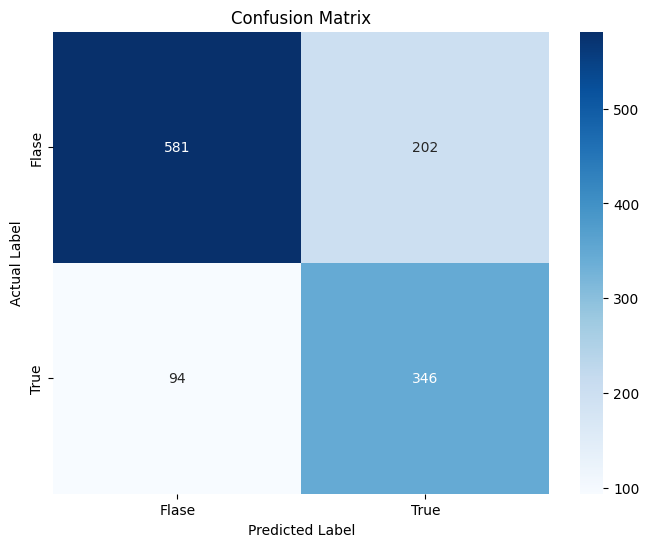

In [28]:
print(f"ALL train data : {len(y_test_classALL)}")
print(f"{pd.DataFrame(y_test_classALL, columns=['y_test_Classify']).value_counts()}")
corr_matrix = plot_confusion_matrix(y_test_classALL, y_pred_smote, ['Flase','True'])

In [29]:
y_prob = rf_smote.predict_proba(X_test_classALL)[:, 1]

from sklearn.metrics import f1_score, recall_score, precision_score
import pandas as pd

results = []
for threshold in [0.3, 0.35, 0.4, 0.45, 0.5]:
    y_pred_t = (y_prob >= threshold).astype(int)
    results.append({
        'Threshold' : threshold,
        'Precision' : precision_score(y_test_classALL, y_pred_t),
        'Recall'    : recall_score(y_test_classALL, y_pred_t),
        'F1-Score'  : f1_score(y_test_classALL, y_pred_t),
    })

df_results = pd.DataFrame(results)
print(df_results)

   Threshold  Precision    Recall  F1-Score
0       0.30   0.579666  0.868182  0.695177
1       0.35   0.602990  0.825000  0.696737
2       0.40   0.631387  0.786364  0.700405
3       0.45   0.665314  0.745455  0.703108
4       0.50   0.696629  0.704545  0.700565


In [30]:
feature_importance(rf_smote,feature_ALL_classify)

Columns have all : 35


,feature,importance
0,Latitude_Degrees,0.11
1,Longitude_Degrees,0.06
2,Depth_m,0.06
5,Temperature_Mean,0.05
3,ClimSST,0.05
10,SSTA,0.04
14,SSTA_Frequency,0.04
4,Temperature_Kelvin,0.04
9,Windspeed,0.04
18,SSTA_DHW,0.04


----------------------

## regression model

- Classification = 1

In [31]:
def PLOTING_RESULT_ML(model, X_test, y_test , cl, name):
    y_test = y_test.ravel()
    y_pred = model.predict(X_test)
    y_pred = y_pred.ravel()

    plt.figure(figsize=(10, 6))

    sns.scatterplot(
        x=y_test,
        y=y_pred,
        alpha=0.5,
        color=cl
    )

    # เส้น ideal line
    plt.plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        color='red',
        linestyle='--',
        lw=2
    )

    plt.title(f'Actual vs Predicted Percent Bleaching {name}')
    plt.xlabel('Actual Bleaching (%)')
    plt.ylabel('Predicted Bleaching (%)')

    plt.grid(True, linestyle=':', alpha=0.6)

    plt.show()

#--------------------------------------------------------------------------------------------------------------------------------------------#

def Metric_result(model , X_train , X_test , y_train , y_test):
    print(f"Score on training data: {(model.score(X_train, y_train)):.2f}") # score from training
    pred = model.predict(X_test)
    print("-" * 30)

    test_mse = mean_squared_error(y_test, pred) # Mean_Squaed_error
    print(f"Test MSE: {test_mse:.2f}")
    print("-" * 30)


    test_rmse = np.sqrt(mean_squared_error(y_test, pred)) # Root_mean_squared_error
    print(f"Test RMSE : {test_rmse:.2f}")
    print("-" * 30)

    test_r2 = r2_score(y_test, pred) # R2_squared
    print(f"Test R2 Score : {test_r2:.2f}")
    print("-" * 30)

    test_mae = mean_absolute_error(y_test, pred) # Mean_Absolute_error
    print(f"Mean Absolute Error : {test_mae:.2f}")
    print("-" * 30)

    test_mape = mean_absolute_percentage_error(y_test, pred) # Mean_Absolute_Percentage_Error
    print(f"Mean Absolute Percentage Error : {test_mape:.2f}")
    print("-" * 30)
    
    print(pred.shape)
    print(y_test.shape)
    
#--------------------------------------------------------------------------------------------------------------------------------------------#

def RESULT_K_FOLD(results, cv):
    r2 = results['test_r2']
    rmse = np.sqrt(-results['test_neg_mean_squared_error'])
    mae = -results['test_neg_mean_absolute_error']

    # สร้างฟังก์ชันย่อยสำหรับจัดรูปแบบ array ให้อ่านง่ายขึ้น
    format_folds = lambda arr: ", ".join([f"{x:.2f}" for x in arr])

    print("=" * 60)
    print(f"{'K-Fold Cross Validation Results (CV = ' + str(cv) + ')':^60}")
    print("=" * 60)
    print(f"{'Metric':<10} | {'Mean (Std)':<15} | {'Scores per Fold'}")
    print("-" * 60)
    
    # เพิ่มการดูค่า Standard Deviation (std) ด้วยเพื่อดูความเสถียรของโมเดล
    print(f"{'R2':<10} | {r2.mean():.2f} (±{r2.std():.2f})   | {format_folds(r2)}")
    print(f"{'RMSE':<10} | {rmse.mean():.2f} (±{rmse.std():.2f})   | {format_folds(rmse)}")
    print(f"{'MAE':<10} | {mae.mean():.2f} (±{mae.std():.2f})   | {format_folds(mae)}")
    print("=" * 60)
    
#--------------------------------------------------------------------------------------------------------------------------------------------#
    
def feature_importance(model, feature_train):
    importances = model.feature_importances_
    feature_names = feature_train.columns
   
    df_importance = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    }).sort_values(by='importance', ascending=False)
    print(f"Columns have all : {len(df_importance)}")
    
    return df_importance.round(2)


#--------------------------------------------------------------------------------------------------------------------------------------------#

def evaluate_model_ML(model, X_test, y_test): # เรียกใช้เมื่อ train โมเดลด้วยข้อมูลทั้งหมดเพราะเป็นการ evaluate กับ ข้อมูลทั้งหมด
    
    y_pred = model.predict(X_test).flatten()

    # ── Inverse transform กลับเป็นค่าจริง ──────────────
    y_pred = y_pred.reshape(-1, 1).flatten()
    y_test = y_test.reshape(-1, 1).flatten()

    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)

    print("=" * 40)
    print("        Model Performance (Real Scale)")
    print("=" * 40)
    print(f"  MSE  : {mse:.4f}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAE  : {mae:.4f}")
    print(f"  R²   : {r2:.4f}")
    print("=" * 40)


In [32]:
df_regression_model = df_Classify_model[df_Classify_model['Classify'] == 1]

In [33]:
df_regression_model.describe()

,Latitude_Degrees,Longitude_Degrees,Depth_m,Percent_Bleaching,ClimSST,Temperature_Kelvin,Temperature_Mean,Temperature_Minimum,Temperature_Maximum,Temperature_Kelvin_Standard_Deviation,...,TSA_Mean,TSA_Frequency,TSA_Frequency_Standard_Deviation,TSA_FrequencyMax,TSA_FrequencyMean,TSA_DHW,TSA_DHW_Standard_Deviation,TSA_DHWMax,TSA_DHWMean,Classify
count,2198.000000,2198.000000,2198.000000,2198.000000,2198.000000,2198.000000,2198.000000,2198.000000,2198.000000,2198.000000,...,2198.000000,2198.000000,2198.000000,2198.000000,2198.000000,2198.000000,2198.000000,2198.000000,2198.000000,2198.0
mean,2.254708,49.772498,6.780619,7.772695,295.360623,301.590299,300.448975,296.021252,305.083371,1.589612,...,-1.760382,2.397220,1.844587,8.428409,1.147294,1.396529,1.482927,10.856739,0.612310,1.0
std,16.217280,104.293593,3.596122,14.814317,13.510389,2.217610,1.675781,2.577289,1.400233,0.702415,...,1.010509,3.133342,0.752462,4.302613,2.092278,3.432011,1.311462,5.630575,1.172151,0.0
min,-28.109167,-179.859361,0.100000,0.010000,262.150000,292.660000,294.710000,284.540000,301.450000,0.800000,...,-7.460000,0.000000,0.680000,3.000000,0.000000,0.000000,0.490000,2.590000,0.130000,1.0
25%,-16.241667,-69.072042,4.000000,0.750000,298.660000,300.510000,299.740000,294.730000,304.330000,1.150000,...,-2.440000,0.000000,1.370000,6.000000,0.000000,0.000000,1.000000,7.360000,0.300000,1.0
50%,6.393639,104.141125,6.000000,2.250000,300.770000,302.130000,300.890000,297.037500,305.200000,1.290000,...,-1.430000,1.500000,1.630000,7.000000,1.000000,0.000000,1.250000,9.520000,0.430000,1.0
75%,15.981111,125.120556,10.000000,7.000000,302.100000,303.139500,301.730000,297.770000,305.805714,2.037500,...,-1.120000,3.333333,2.110000,9.500000,1.000000,1.380000,1.651500,12.470000,0.640000,1.0
max,34.056111,179.943833,21.700000,100.000000,304.010000,306.800000,303.240000,299.880000,313.140000,5.820000,...,-0.010000,24.000000,13.570000,52.000000,20.000000,37.680000,15.210000,63.470000,12.660000,1.0


In [34]:
print(f"total number of rows and columns in the dataset: {len(df_regression_model.columns)} columns, {len(df_regression_model)} rows") # มี classify ด้วย

total number of rows and columns in the dataset: 37 columns, 2198 rows


==========================
## Baseline
==========================

In [35]:
# แยก Feature และ Target
feature_reg_Baseline = df_regression_model[['Latitude_Degrees', 'Longitude_Degrees', 'Depth_m', 'SSTA', 'ClimSST']]
target_reg_Baseline = df_regression_model[['Percent_Bleaching']]

X_reg_trainBaseline_values = feature_reg_Baseline.values
y_reg_trainBaseline_values = target_reg_Baseline.values

def set_datapretrain_reg(X, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42  # ไม่มี stratify
    )
    return X_train, X_test, y_train, y_test

# เรียกใช้
X_trainBaseline_reg, X_testBaseline_reg, y_trainBaseline_reg, y_testBaseline_reg = set_datapretrain_reg(
    X_reg_trainBaseline_values, y_reg_trainBaseline_values
)

# 1. สร้างโมเดล XGBoost พร้อมตั้งค่าพารามิเตอร์เบื้องต้นเพื่อกัน Overfit
model_xgbBaseline = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.01,   # ใจเย็นๆ ค่อยๆ เดิน
    max_depth=4,          # ไม่ลึกเกินไปจนจำคำตอบ
    subsample=0.8,        # สุ่มข้อมูล
    colsample_bytree=0.8, # สุ่ม Feature
    reg_alpha=0.1,        # L1 Regularization
    reg_lambda=1.0,       # L2 Regularization
    random_state=42
)
# 2. เทรนโมเดล
model_xgbBaseline.fit(X_trainBaseline_reg, y_trainBaseline_reg)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

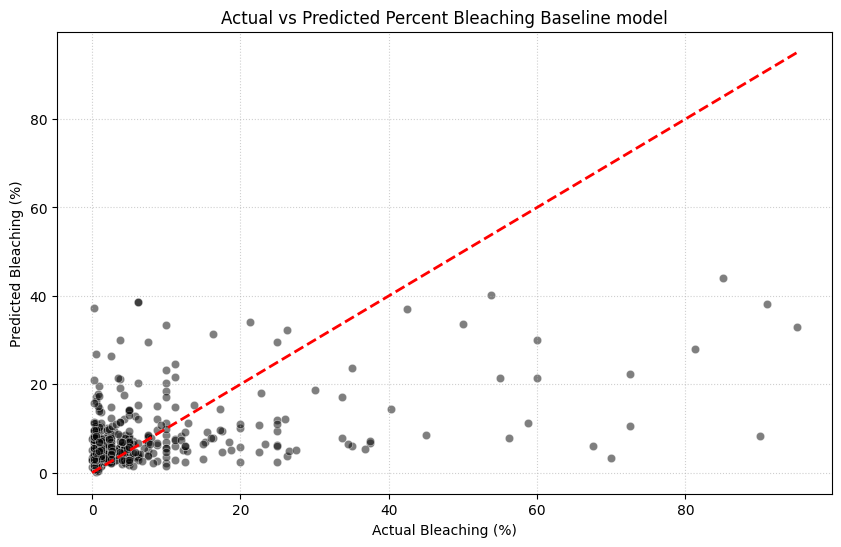

In [36]:
PLOTING_RESULT_ML(model_xgbBaseline, X_testBaseline_reg, y_testBaseline_reg, 'black', 'Baseline model')

In [37]:
Metric_result(model_xgbBaseline, X_trainBaseline_reg, X_testBaseline_reg, y_trainBaseline_reg, y_testBaseline_reg)

Score on training data: 0.60
------------------------------
Test MSE: 166.83
------------------------------
Test RMSE : 12.92
------------------------------
Test R2 Score : 0.22
------------------------------
Mean Absolute Error : 7.49
------------------------------
Mean Absolute Percentage Error : 7.35
------------------------------
(440,)
(440, 1)


------------------------------

In [38]:
# แยก Feature และ Target
feature_reg = df_regression_model.drop(columns=['Classify', 'Percent_Bleaching'])
target_reg = df_regression_model[['Percent_Bleaching']]

X_reg_train_values = feature_reg.values
y_train_reg_values = target_reg.values

def set_datapretrain_reg(X, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42  # ไม่มี stratify
    )
    return X_train, X_test, y_train, y_test

# เรียกใช้
X_train_reg, X_test_reg, y_train_reg, y_test_reg = set_datapretrain_reg(
    X_reg_train_values, y_train_reg_values
)

# 1. สร้างโมเดล XGBoost พร้อมตั้งค่าพารามิเตอร์เบื้องต้นเพื่อกัน Overfit
model_xgb = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.01,   # ใจเย็นๆ ค่อยๆ เดิน
    max_depth=4,          # ไม่ลึกเกินไปจนจำคำตอบ
    subsample=0.8,        # สุ่มข้อมูล
    colsample_bytree=0.8, # สุ่ม Feature
    reg_alpha=0.1,        # L1 Regularization
    reg_lambda=1.0,       # L2 Regularization
    random_state=42
)
# 2. เทรนโมเดล
model_xgb.fit(X_train_reg, y_train_reg)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [39]:
X_train_reg.shape , X_test_reg.shape , y_train_reg.shape , y_test_reg.shape

((1758, 35), (440, 35), (1758, 1), (440, 1))

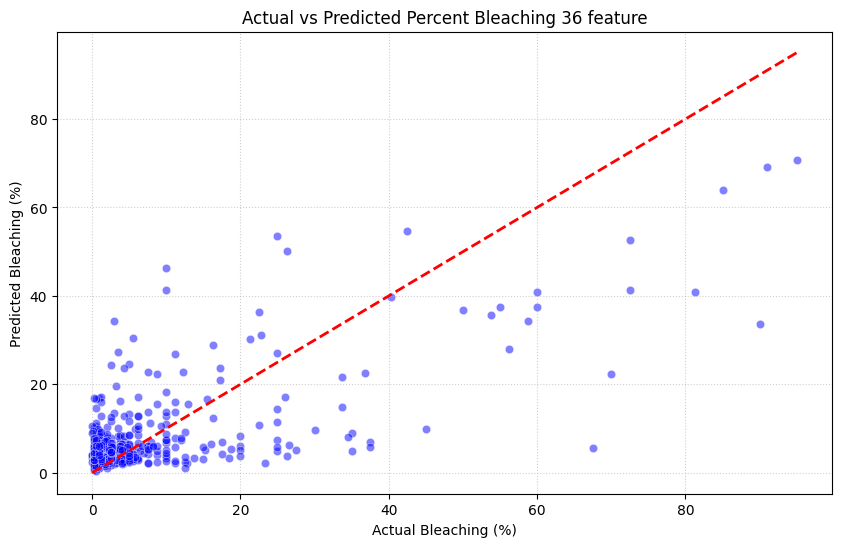

In [40]:
PLOTING_RESULT_ML(model_xgb, X_test_reg, y_test_reg, 'blue', '36 feature')

In [41]:
Metric_result(model_xgb, X_train_reg, X_test_reg, y_train_reg, y_test_reg)

Score on training data: 0.78
------------------------------
Test MSE: 102.85
------------------------------
Test RMSE : 10.14
------------------------------
Test R2 Score : 0.52
------------------------------
Mean Absolute Error : 6.18
------------------------------
Mean Absolute Percentage Error : 6.88
------------------------------
(440,)
(440, 1)


In [42]:
feature_importance(model_xgb,feature_reg)

Columns have all : 35


,feature,importance
28,TSA_Frequency_Standard_Deviation,0.08
29,TSA_FrequencyMax,0.06
8,Temperature_Kelvin_Standard_Deviation,0.05
26,TSA_Mean,0.04
6,Temperature_Minimum,0.04
31,TSA_DHW,0.04
11,SSTA_Standard_Deviation,0.04
17,SSTA_FrequencyMean,0.04
13,SSTA_Maximum,0.03
23,TSA_Standard_Deviation,0.03


In [43]:
#------------------------------------------------------------------------#
# โมเดล Average bleaching
#------------------------------------------------------------------------#


y_pred_Averagemodel = df_regression_model[['Percent_Bleaching']].mean()

def RMSE(df):
    y_true = df['Percent_Bleaching'].values
    total = 0
    
    for i in range(len(y_true)):
        error = y_true[i] - y_pred_Averagemodel
        total += error**2
    
    rmse = np.sqrt(total / len(y_true))
    return rmse

print(f"RMSE : {RMSE(df_regression_model).round(2)}")

def R2_score(df):
    y_true = df['Percent_Bleaching'].values
    
    y_mean = np.mean(y_true)
    
    ss_res = 0  # sum of squared residuals
    ss_tot = 0  # total sum of squares
    
    for i in range(len(y_true)):
        ss_res += (y_true[i] - y_pred_Averagemodel)**2
        ss_tot += (y_true[i] - y_mean)**2
    
    r2 = 1 - (ss_res / ss_tot)
    
    print(f"SS_res : {ss_res.round(1)}")
    print(f"SS_tot : {ss_tot.round(1)}")
    
    return r2

print(f"Percent_bleaching : {y_pred_Averagemodel}")
print("-"*50)
print(f"R2_score (rounded): {R2_score(df_regression_model)}") # predicted less than mean so R2 is negative

RMSE : Percent_Bleaching    14.81
dtype: float64
Percent_bleaching : Percent_Bleaching    7.772695
dtype: float64
--------------------------------------------------
SS_res : Percent_Bleaching    482162.4
dtype: float64
SS_tot : 482162.4
R2_score (rounded): Percent_Bleaching    0.0
dtype: float64


----------------------

### ลบ feature ที่ correlation กันสูงมากๆ

In [44]:
# กลุ่มตัวแปรที่ควร Drop ทิ้ง เพราะซ้ำซ้อนและอธิบายสิ่งเดียวกัน
#Find highly correlated pairs
corr_matrix = df_regression_model.corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape),k=1).astype(bool))
#print(upper_tri)
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.80)]
print(f"High correlation : {len(to_drop)}")
print(to_drop)   

High correlation : 17
['Temperature_Minimum', 'Temperature_Kelvin_Standard_Deviation', 'SSTA_FrequencyMax', 'SSTA_FrequencyMean', 'SSTA_DHW_Standard_Deviation', 'SSTA_DHWMax', 'SSTA_DHWMean', 'TSA', 'TSA_Standard_Deviation', 'TSA_Minimum', 'TSA_Maximum', 'TSA_Mean', 'TSA_FrequencyMax', 'TSA_FrequencyMean', 'TSA_DHW_Standard_Deviation', 'TSA_DHWMax', 'TSA_DHWMean']


In [45]:
df_clean = df_regression_model.drop(columns=to_drop, errors='ignore')
df_clean

,Latitude_Degrees,Longitude_Degrees,Depth_m,Percent_Bleaching,ClimSST,Temperature_Kelvin,Temperature_Mean,Temperature_Maximum,Windspeed,SSTA,SSTA_Standard_Deviation,SSTA_Minimum,SSTA_Maximum,SSTA_Frequency,SSTA_Frequency_Standard_Deviation,SSTA_DHW,TSA_Frequency,TSA_Frequency_Standard_Deviation,TSA_DHW,Classify
0,-20.899833,149.407722,4.0,6.25,297.78,301.67,298.17,303.85,5.0,1.32,0.87,-3.210000,2.83,12.0,5.49,3.96,3.0,1.95,3.52,1
1,-20.893056,149.421000,5.0,8.75,297.78,301.67,298.17,303.85,5.0,1.32,0.87,-3.210000,2.83,12.0,5.49,3.96,3.0,1.95,3.52,1
2,-20.745806,149.472056,6.0,11.25,298.17,301.38,298.34,303.76,5.0,0.87,0.82,-2.701111,2.60,10.0,5.67,2.68,1.0,1.47,1.51,1
3,-20.737694,149.464944,5.0,25.00,298.21,301.56,298.37,304.04,5.0,1.07,0.81,-2.803333,3.44,8.0,5.27,3.65,2.0,1.31,2.36,1
4,-20.259361,148.814583,2.0,1.00,296.48,296.38,298.47,304.54,4.0,1.76,0.93,-3.268571,3.15,17.0,6.12,3.84,4.0,1.72,0.00,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9634,15.971389,108.491389,6.7,0.75,302.17,301.28,299.47,305.39,3.0,0.27,1.07,-3.766667,3.65,6.0,6.24,0.00,2.0,1.71,0.00,1
9635,15.972222,108.421667,3.0,1.50,301.70,301.08,299.42,304.98,3.0,0.55,1.02,-4.093333,3.19,6.0,5.55,0.00,2.0,1.62,0.00,1
9637,15.977222,108.500556,10.0,2.00,302.17,301.28,299.47,305.39,3.0,0.27,1.07,-3.766667,3.65,6.0,6.24,0.00,2.0,1.71,0.00,1
9638,15.979444,108.448611,5.0,4.50,302.19,302.10,299.46,305.35,3.0,0.89,1.05,-3.948889,3.41,6.0,5.41,0.00,2.0,1.67,0.00,1


In [46]:
# แยก Feature และ Target
feature_reg_clean = df_clean.drop(columns=['Classify', 'Percent_Bleaching'])
target_reg_clean = df_clean[['Percent_Bleaching']]

X_reg_trainClean_values = feature_reg_clean.values
y_reg_trainClean_values = target_reg_clean.values

def set_datapretrain_reg(X, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42  # ไม่มี stratify
    )
    return X_train, X_test, y_train, y_test

# เรียกใช้
X_train_regClean, X_test_regClean, y_train_regClean, y_test_regClean = set_datapretrain_reg(
    X_reg_trainClean_values, y_reg_trainClean_values
)

# 1. สร้างโมเดล XGBoost พร้อมตั้งค่าพารามิเตอร์เบื้องต้นเพื่อกัน Overfit
model_xgbClean = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.01,   # ใจเย็นๆ ค่อยๆ เดิน
    max_depth=4,          # ไม่ลึกเกินไปจนจำคำตอบ
    subsample=0.8,        # สุ่มข้อมูล
    colsample_bytree=0.8, # สุ่ม Feature
    reg_alpha=0.1,        # L1 Regularization
    reg_lambda=1.0,       # L2 Regularization
    random_state=42
)
# 2. เทรนโมเดล
#weights = np.where(y_train_regClean > 50, 2.0, 1.0)
model_xgbClean.fit(X_train_regClean, y_train_regClean)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

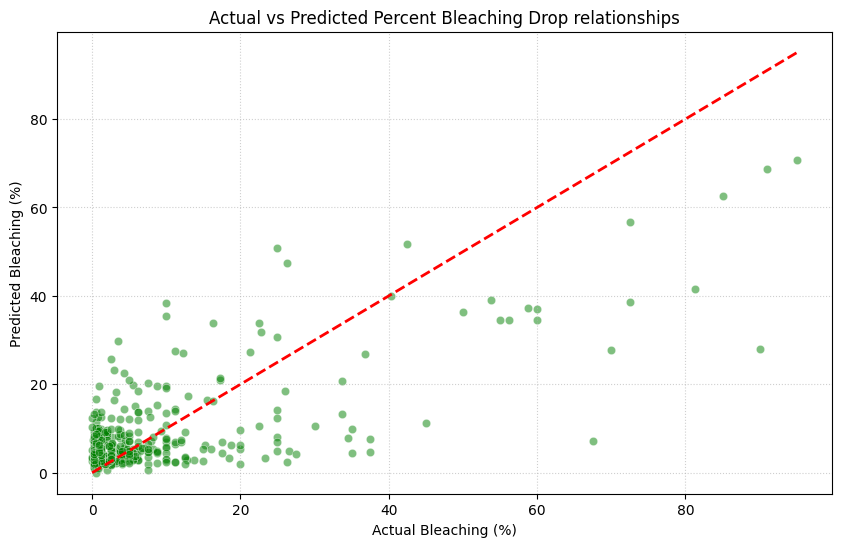

In [47]:
PLOTING_RESULT_ML(model_xgbClean, X_test_regClean, y_test_regClean, 'green', 'Drop relationships')

In [48]:
Metric_result(model_xgbClean, X_train_regClean, X_test_regClean, y_train_regClean, y_test_regClean)

Score on training data: 0.77
------------------------------
Test MSE: 97.91
------------------------------
Test RMSE : 9.90
------------------------------
Test R2 Score : 0.54
------------------------------
Mean Absolute Error : 6.08
------------------------------
Mean Absolute Percentage Error : 7.28
------------------------------
(440,)
(440, 1)


In [49]:
feature_importance(model_xgbClean,feature_reg_clean)

Columns have all : 18


,feature,importance
16,TSA_Frequency_Standard_Deviation,0.11
17,TSA_DHW,0.08
9,SSTA_Standard_Deviation,0.08
10,SSTA_Minimum,0.07
11,SSTA_Maximum,0.06
1,Longitude_Degrees,0.06
15,TSA_Frequency,0.05
12,SSTA_Frequency,0.05
0,Latitude_Degrees,0.05
14,SSTA_DHW,0.05


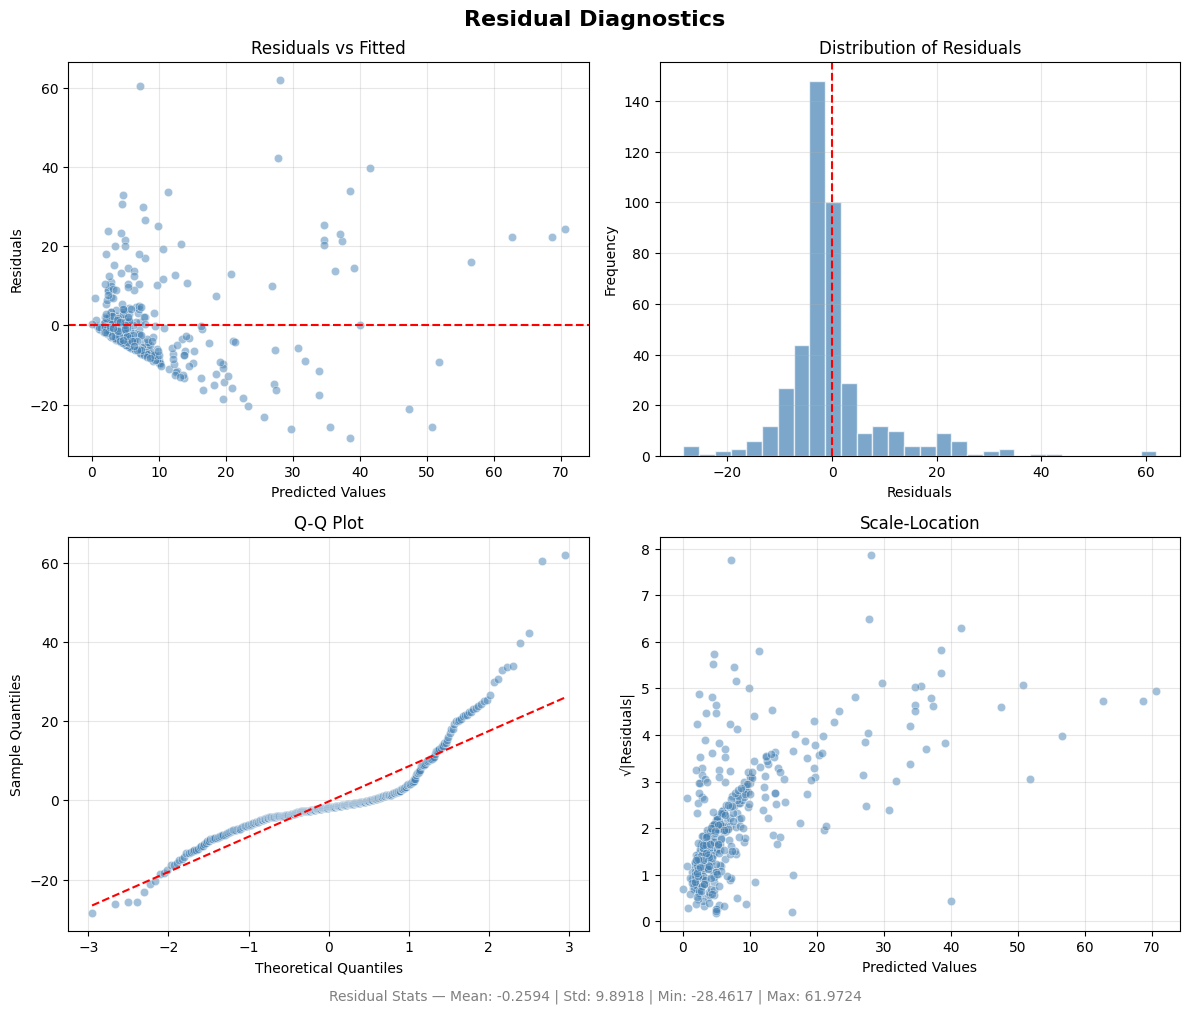

In [50]:
y_pred_modelClean = model_xgbClean.predict(X_test_regClean)

# แปลงให้เป็น numpy array ทั้งคู่ก่อนคำนวณ
y_test_array = np.array(y_test_regClean).ravel()   # .ravel() กันกรณี shape เป็น (n,1)
y_pred_array = np.array(y_pred_modelClean).ravel()

residuals = y_test_array - y_pred_array


fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Residual Diagnostics', fontsize=16, fontweight='bold')

# 1. Residuals vs Fitted
axes[0, 0].scatter(y_pred_modelClean, residuals, alpha=0.5, color='steelblue', edgecolors='white', linewidth=0.5)
axes[0, 0].axhline(y=0, color='r', linestyle='--', linewidth=1.5)
axes[0, 0].set_xlabel('Predicted Values')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].set_title('Residuals vs Fitted')
axes[0, 0].grid(True, alpha=0.3)

# 2. Histogram of Residuals
axes[0, 1].hist(residuals, bins=30, color='steelblue', edgecolor='white', alpha=0.7)
axes[0, 1].axvline(x=0, color='r', linestyle='--', linewidth=1.5)
axes[0, 1].set_xlabel('Residuals')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Residuals')
axes[0, 1].grid(True, alpha=0.3)

# 3. Q-Q Plot
from scipy import stats
(osm, osr), (slope, intercept, r) = stats.probplot(residuals, dist="norm")
axes[1, 0].scatter(osm, osr, alpha=0.5, color='steelblue', edgecolors='white', linewidth=0.5)
axes[1, 0].plot(osm, slope * np.array(osm) + intercept, color='r', linestyle='--', linewidth=1.5)
axes[1, 0].set_xlabel('Theoretical Quantiles')
axes[1, 0].set_ylabel('Sample Quantiles')
axes[1, 0].set_title('Q-Q Plot')
axes[1, 0].grid(True, alpha=0.3)

# 4. Scale-Location (sqrt of absolute residuals vs fitted)
sqrt_abs_residuals = np.sqrt(np.abs(residuals))
axes[1, 1].scatter(y_pred_modelClean, sqrt_abs_residuals, alpha=0.5, color='steelblue', edgecolors='white', linewidth=0.5)
axes[1, 1].set_xlabel('Predicted Values')
axes[1, 1].set_ylabel('√|Residuals|')
axes[1, 1].set_title('Scale-Location')
axes[1, 1].grid(True, alpha=0.3)

# Stats annotation
mean_res = np.mean(residuals)
std_res  = np.std(residuals)
fig.text(0.5, -0.01,
         f'Residual Stats — Mean: {mean_res:.4f} | Std: {std_res:.4f} | Min: {np.min(residuals):.4f} | Max: {np.max(residuals):.4f}',
         ha='center', fontsize=10, color='gray')

plt.tight_layout()
plt.show()

##

##

## Feature engineering ช่วย

In [51]:
df_feature_Engineering = df_regression_model.copy()
df_feature_Engineering

,Latitude_Degrees,Longitude_Degrees,Depth_m,Percent_Bleaching,ClimSST,Temperature_Kelvin,Temperature_Mean,Temperature_Minimum,Temperature_Maximum,Temperature_Kelvin_Standard_Deviation,...,TSA_Mean,TSA_Frequency,TSA_Frequency_Standard_Deviation,TSA_FrequencyMax,TSA_FrequencyMean,TSA_DHW,TSA_DHW_Standard_Deviation,TSA_DHWMax,TSA_DHWMean,Classify
0,-20.899833,149.407722,4.0,6.25,297.78,301.67,298.17,291.91,303.85,2.74,...,-3.26,3.0,1.95,7.0,1.0,3.52,1.36,8.43,0.52,1
1,-20.893056,149.421000,5.0,8.75,297.78,301.67,298.17,291.91,303.85,2.74,...,-3.26,3.0,1.95,7.0,1.0,3.52,1.36,8.43,0.52,1
2,-20.745806,149.472056,6.0,11.25,298.17,301.38,298.34,292.67,303.76,2.57,...,-3.06,1.0,1.47,5.0,1.0,1.51,1.23,7.32,0.49,1
3,-20.737694,149.464944,5.0,25.00,298.21,301.56,298.37,292.01,304.04,2.52,...,-3.01,2.0,1.31,5.0,1.0,2.36,0.97,6.86,0.36,1
4,-20.259361,148.814583,2.0,1.00,296.48,296.38,298.47,291.83,304.54,2.70,...,-3.23,4.0,1.72,7.0,1.0,0.00,1.47,9.84,0.56,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9634,15.971389,108.491389,6.7,0.75,302.17,301.28,299.47,293.10,305.39,2.69,...,-3.19,2.0,1.71,7.0,1.0,0.00,1.33,8.75,0.53,1
9635,15.972222,108.421667,3.0,1.50,301.70,301.08,299.42,292.99,304.98,2.62,...,-3.03,2.0,1.62,7.0,1.0,0.00,1.25,10.60,0.43,1
9637,15.977222,108.500556,10.0,2.00,302.17,301.28,299.47,293.10,305.39,2.69,...,-3.19,2.0,1.71,7.0,1.0,0.00,1.33,8.75,0.53,1
9638,15.979444,108.448611,5.0,4.50,302.19,302.10,299.46,293.04,305.35,2.65,...,-3.12,2.0,1.67,7.0,1.0,0.00,1.28,9.05,0.48,1


In [52]:
def Plotting_feature_target(df,col_feature, col_target='Percent_Bleaching'):
    
    X = df[col_feature]
    y = df[col_target]
    
    plt.figure(figsize=(6,4))
    plt.scatter(X, y, color='white', edgecolor='black', alpha=0.7)
    plt.xlabel(col_feature)
    plt.ylabel(col_target)
    plt.title(f'{col_feature} vs {col_target}')
    plt.show()

In [53]:
def plotting_distribution(data, columns):
    for col in columns:
        norm_fit = ss.norm.fit(data[col])
        datasortvalues = data[col].sort_values()
        plt.figure(figsize=(8,6))
        plt.hist(data[[col]], density=True, bins=30, color='skyblue', edgecolor='black')
        plt.plot(datasortvalues, ss.norm.pdf(datasortvalues, *norm_fit), color='red', linewidth=2)
        plt.xlabel(col)
        plt.ylabel('Density')
        plt.title(f'Distribution of {col}')
        plt.show()

##

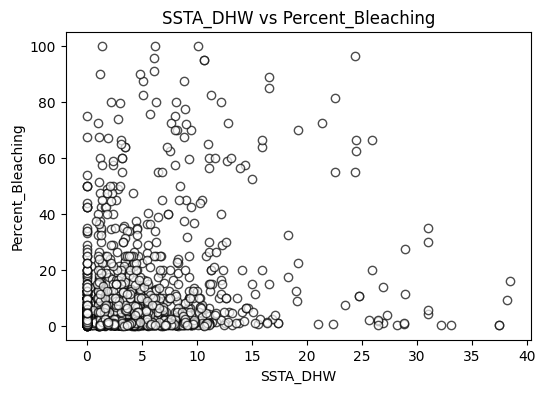

Correlation : 0.229


In [54]:
Plotting_feature_target(df_feature_Engineering,'SSTA_DHW')
print(f"Correlation : {df_feature_Engineering['SSTA_DHW'].corr(df_feature_Engineering['Percent_Bleaching']):.3f}")

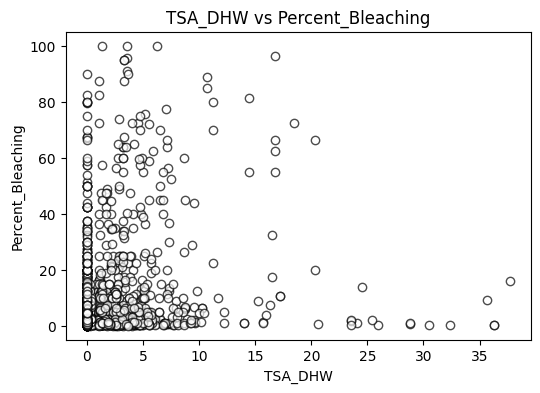

Correlation : 0.204


In [55]:
Plotting_feature_target(df_feature_Engineering,'TSA_DHW')
print(f"Correlation : {df_feature_Engineering['TSA_DHW'].corr(df_feature_Engineering['Percent_Bleaching']):.3f}")

-------------

In [56]:
to_dropEN = [
             'Temperature_Minimum', 
             'Temperature_Kelvin_Standard_Deviation', 
             'Temperature_Kelvin',
             'SSTA_FrequencyMax', 
             'SSTA_FrequencyMean', 
             'SSTA_DHW_Standard_Deviation', 
             'SSTA_DHWMax', 
             'SSTA_DHWMean', 
             'TSA', 
             'TSA_Standard_Deviation', 
             'TSA_Minimum', 
             'TSA_Maximum', 
             'TSA_Mean', 
             'TSA_FrequencyMax', 
             'TSA_FrequencyMean', 
             'TSA_DHW_Standard_Deviation', 
             'TSA_DHWMax', 
             'TSA_DHWMean'
            ]

In [57]:
df_feature_Engineering_Clean = df_feature_Engineering.drop(columns=to_dropEN)

In [58]:
# แยก Feature และ Target
feature_reg_En = df_feature_Engineering_Clean.drop(columns=['Classify', 'Percent_Bleaching'])
target_reg_En = df_feature_Engineering_Clean[['Percent_Bleaching']]

X_reg_trainEn_values = feature_reg_En.values
y_reg_trainEn_values = target_reg_En.values

def set_datapretrain_reg(X, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42  # ไม่มี stratify
    )
    return X_train, X_test, y_train, y_test

# เรียกใช้
X_train_regEn, X_test_regEn, y_train_regEn, y_test_regEn = set_datapretrain_reg(
    X_reg_trainEn_values, y_reg_trainEn_values
)

# 1. สร้างโมเดล XGBoost พร้อมตั้งค่าพารามิเตอร์เบื้องต้นเพื่อกัน Overfit
model_xgbEn = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.01,   # ใจเย็นๆ ค่อยๆ เดิน
    max_depth=4,          # ไม่ลึกเกินไปจนจำคำตอบ
    subsample=0.8,        # สุ่มข้อมูล
    colsample_bytree=0.8, # สุ่ม Feature
    reg_alpha=0.1,        # L1 Regularization
    reg_lambda=1.0,       # L2 Regularization
    random_state=42
)
# 2. เทรนโมเดล
#weights = np.where(y_train_regClean > 50, 2.0, 1.0)
model_xgbEn.fit(X_train_regEn, y_train_regEn)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [59]:
Metric_result(model_xgbEn, X_train_regEn, X_test_regEn, y_train_regEn,y_test_regEn)

Score on training data: 0.76
------------------------------
Test MSE: 97.58
------------------------------
Test RMSE : 9.88
------------------------------
Test R2 Score : 0.54
------------------------------
Mean Absolute Error : 6.13
------------------------------
Mean Absolute Percentage Error : 7.51
------------------------------
(440,)
(440, 1)


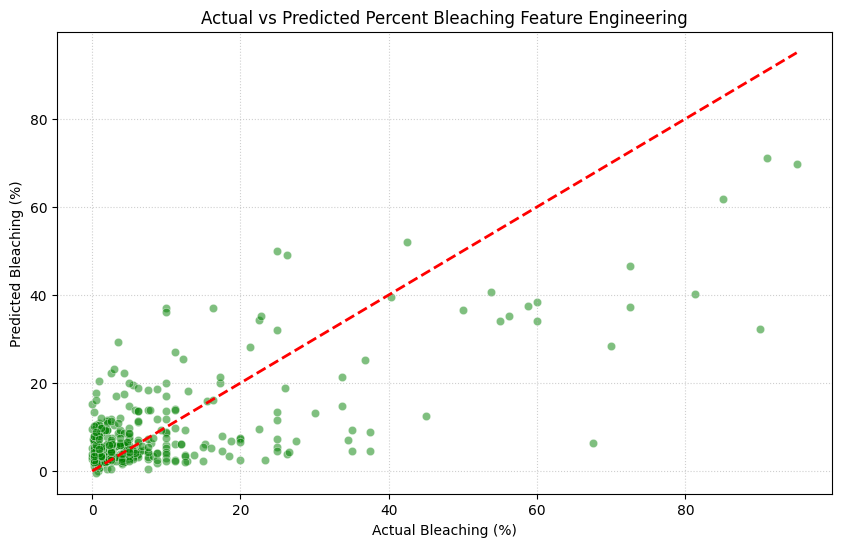

In [60]:
PLOTING_RESULT_ML(model_xgbEn, X_test_regEn, y_test_regEn, 'green', 'Feature Engineering')

In [61]:
feature_reg_En

,Latitude_Degrees,Longitude_Degrees,Depth_m,ClimSST,Temperature_Mean,Temperature_Maximum,Windspeed,SSTA,SSTA_Standard_Deviation,SSTA_Minimum,SSTA_Maximum,SSTA_Frequency,SSTA_Frequency_Standard_Deviation,SSTA_DHW,TSA_Frequency,TSA_Frequency_Standard_Deviation,TSA_DHW
0,-20.899833,149.407722,4.0,297.78,298.17,303.85,5.0,1.32,0.87,-3.210000,2.83,12.0,5.49,3.96,3.0,1.95,3.52
1,-20.893056,149.421000,5.0,297.78,298.17,303.85,5.0,1.32,0.87,-3.210000,2.83,12.0,5.49,3.96,3.0,1.95,3.52
2,-20.745806,149.472056,6.0,298.17,298.34,303.76,5.0,0.87,0.82,-2.701111,2.60,10.0,5.67,2.68,1.0,1.47,1.51
3,-20.737694,149.464944,5.0,298.21,298.37,304.04,5.0,1.07,0.81,-2.803333,3.44,8.0,5.27,3.65,2.0,1.31,2.36
4,-20.259361,148.814583,2.0,296.48,298.47,304.54,4.0,1.76,0.93,-3.268571,3.15,17.0,6.12,3.84,4.0,1.72,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9634,15.971389,108.491389,6.7,302.17,299.47,305.39,3.0,0.27,1.07,-3.766667,3.65,6.0,6.24,0.00,2.0,1.71,0.00
9635,15.972222,108.421667,3.0,301.70,299.42,304.98,3.0,0.55,1.02,-4.093333,3.19,6.0,5.55,0.00,2.0,1.62,0.00
9637,15.977222,108.500556,10.0,302.17,299.47,305.39,3.0,0.27,1.07,-3.766667,3.65,6.0,6.24,0.00,2.0,1.71,0.00
9638,15.979444,108.448611,5.0,302.19,299.46,305.35,3.0,0.89,1.05,-3.948889,3.41,6.0,5.41,0.00,2.0,1.67,0.00


In [62]:
feature_importance(model_xgbEn,feature_reg_En)

Columns have all : 17


,feature,importance
15,TSA_Frequency_Standard_Deviation,0.11
8,SSTA_Standard_Deviation,0.08
16,TSA_DHW,0.08
9,SSTA_Minimum,0.08
10,SSTA_Maximum,0.06
14,TSA_Frequency,0.06
11,SSTA_Frequency,0.06
1,Longitude_Degrees,0.06
13,SSTA_DHW,0.06
0,Latitude_Degrees,0.06


##

## หา Feature ที่จะนำมาทำ Feature Engineering

In [63]:
def plotting_distribution(data, columns):
    for col in columns:
        norm_fit = ss.norm.fit(data[col])
        datasortvalues = data[col].sort_values()
        plt.figure(figsize=(8,6))
        plt.hist(data[[col]], density=True, bins=30, color='skyblue', edgecolor='black')
        plt.plot(datasortvalues, ss.norm.pdf(datasortvalues, *norm_fit), color='red', linewidth=2)
        plt.xlabel(col)
        plt.ylabel('Density')
        plt.title(f'Distribution of {col}')
        plt.show()

In [64]:
df_discover_feature = df_feature_Engineering[df_feature_Engineering['Percent_Bleaching'] >= 1]
df_discover_feature[['Percent_Bleaching']].describe()

,Percent_Bleaching
count,1599.000000
mean,10.528702
std,16.547607
min,1.000000
25%,1.750000
50%,4.250000
75%,10.000000
max,100.000000


In [65]:
# DHW_combination = SSTA_DHW * TSA_DHW
df_discover_feature['DHW_combination'] = df_discover_feature['SSTA_DHW'] * df_discover_feature['TSA_DHW']
df_discover_feature['SSTA_DHW_combination_Depth'] = df_discover_feature['SSTA_DHW'] * np.sqrt(df_discover_feature['Depth_m'])
df_discover_feature['SSTA_DHW_Divide_Depth'] = df_discover_feature['SSTA_DHW'] / df_discover_feature['Depth_m']
df_discover_feature['Depth_Divide_SSTA_DHW'] = df_discover_feature['Depth_m'] / np.log1p(df_discover_feature['SSTA_DHW'] + 1.01)

C:\Users\superuser\AppData\Local\Temp\ipykernel_14196\1894776807.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_discover_feature['DHW_combination'] = df_discover_feature['SSTA_DHW'] * df_discover_feature['TSA_DHW']
C:\Users\superuser\AppData\Local\Temp\ipykernel_14196\1894776807.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_discover_feature['SSTA_DHW_combination_Depth'] = df_discover_feature['SSTA_DHW'] * np.sqrt(df_discover_feature['Depth_m'])
C:\Users\superuser\AppData\Local\Temp\ipykerne

In [66]:
print(f"Correlation SSTA_DHW vs Precent_Bleaching : {df_discover_feature['SSTA_DHW'].corr(df_discover_feature['Percent_Bleaching']):.3f}")
print(f"Correlation Depth_m vs Precent_Bleaching : {df_discover_feature['Depth_m'].corr(df_discover_feature['Percent_Bleaching']):.3f}")
print(f"Correlation SSTA_DHW_combination_Depth vs Precent_Bleaching : {df_discover_feature['SSTA_DHW_combination_Depth'].corr(df_discover_feature['Percent_Bleaching']):.3f}")
print(f"Correlation SSTA_DHW_Divide_Depth vs Precent_Bleaching : {df_discover_feature['SSTA_DHW_Divide_Depth'].corr(df_discover_feature['Percent_Bleaching']):.3f}")
print(f"Correlation Depth_Divide_SSTA_DHW vs Precent_Bleaching : {df_discover_feature['Depth_Divide_SSTA_DHW'].corr(df_discover_feature['Percent_Bleaching']):.3f}")

Correlation SSTA_DHW vs Precent_Bleaching : 0.253
Correlation Depth_m vs Precent_Bleaching : 0.009
Correlation SSTA_DHW_combination_Depth vs Precent_Bleaching : 0.261
Correlation SSTA_DHW_Divide_Depth vs Precent_Bleaching : 0.058
Correlation Depth_Divide_SSTA_DHW vs Precent_Bleaching : -0.123


In [67]:
def covariance(x, y):
    mean_x = x.mean()
    mean_y = y.mean()

    total = 0

    for i in range(len(x)):
        total += (x.iloc[i] - mean_x) * (y.iloc[i] - mean_y)

    cov = total / (len(x) - 1)

    return cov.round(3)

print(f"Covariance SSTA vs Percent_Bleaching : {covariance(df_discover_feature['SSTA_DHW'], df_discover_feature['Percent_Bleaching'])}")
print(f"Covariance Depth_m vs Percent_Bleaching : {covariance(df_discover_feature['Depth_m'], df_discover_feature['Percent_Bleaching'])}")
print(f"Covariance SSTA_DHW_combination_Depth vs Percent_Bleaching : {covariance(df_discover_feature['SSTA_DHW_combination_Depth'], df_discover_feature['Percent_Bleaching'])}")
print(f"Covariance SSTA_Divide_Depth vs Percent_Bleaching : {covariance(df_discover_feature['SSTA_DHW_Divide_Depth'], df_discover_feature['Percent_Bleaching'])}")
print(f"Covariance Depth_Divide_SSTA_DHW vs Percent_Bleaching : {covariance(df_discover_feature['Depth_Divide_SSTA_DHW'], df_discover_feature['Percent_Bleaching'])}")

Covariance SSTA vs Percent_Bleaching : 20.08
Covariance Depth_m vs Percent_Bleaching : 0.551
Covariance SSTA_DHW_combination_Depth vs Percent_Bleaching : 49.75
Covariance SSTA_Divide_Depth vs Percent_Bleaching : 2.938
Covariance Depth_Divide_SSTA_DHW vs Percent_Bleaching : -8.678


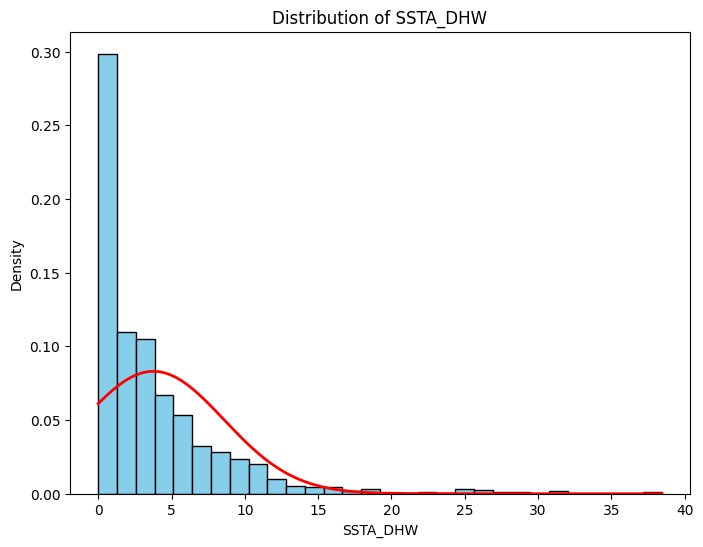

In [68]:
plotting_distribution(df_discover_feature,['SSTA_DHW'])

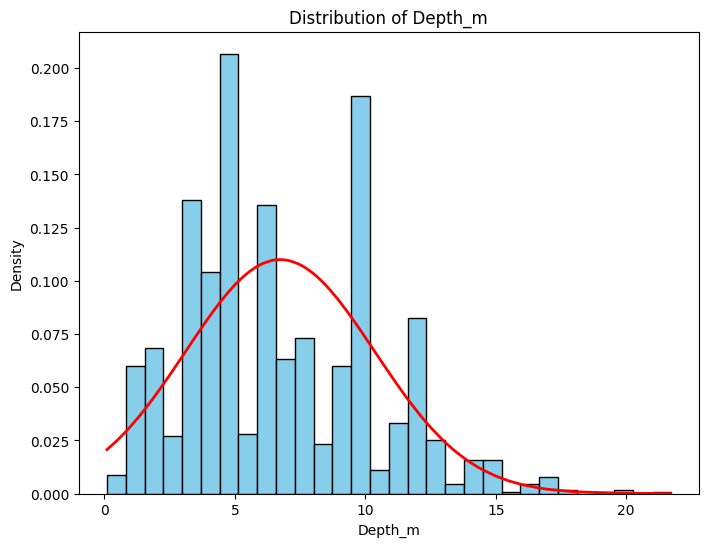

In [69]:
plotting_distribution(df_discover_feature,['Depth_m'])

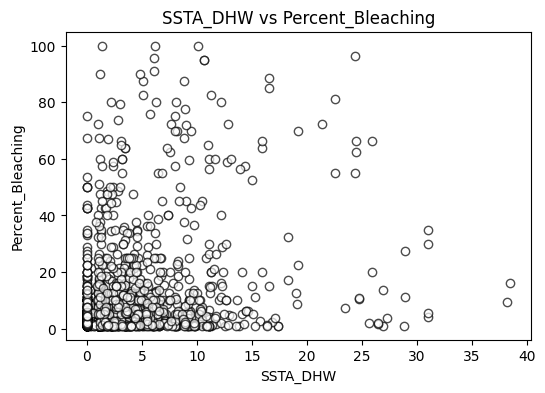

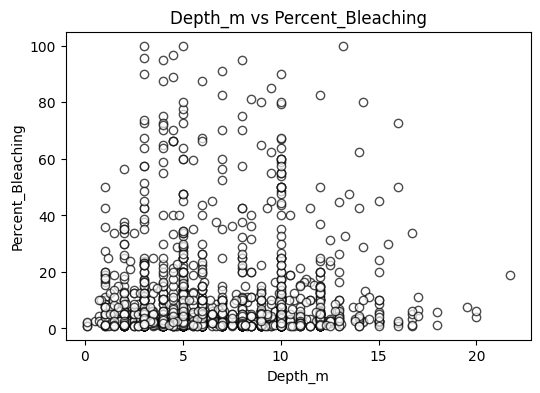

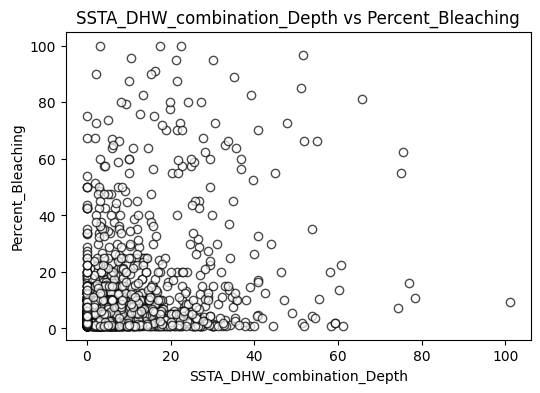

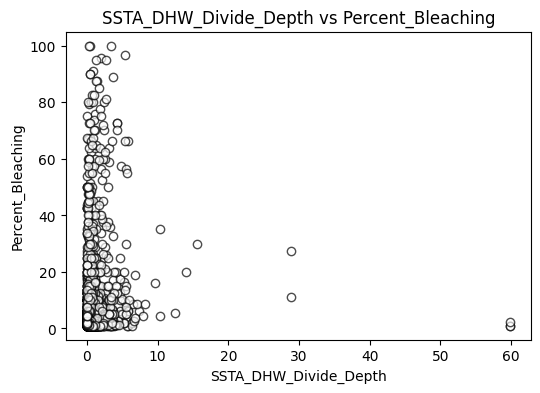

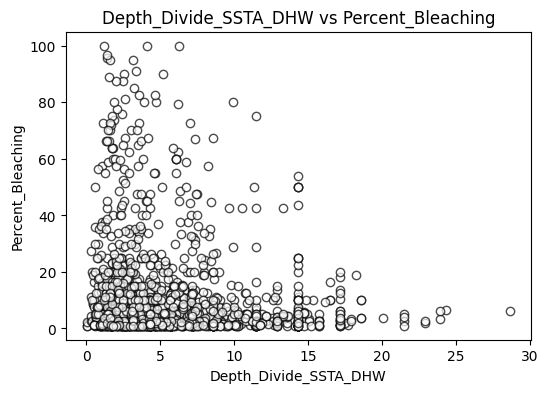

In [70]:
col_needcheck = ['SSTA_DHW', 'Depth_m', 'SSTA_DHW_combination_Depth', 'SSTA_DHW_Divide_Depth', 'Depth_Divide_SSTA_DHW']
for i in col_needcheck:
    Plotting_feature_target(df_discover_feature,i)

In [73]:
from scipy.stats import spearmanr

def Spearman(df,col_x,col_y='Percent_Bleaching'):
    corr, p_value = spearmanr(
        df[col_x],
        df[col_y]
    )

    print("Spearman :", corr.round(3))
    print("P-value :", p_value.round(3))
    
print("SSTA_DHW vs % Bleaching")
print(Spearman(df_discover_feature, 'SSTA_DHW'))
print("="*30)
print("Depth vs % Bleaching")
print(Spearman(df_discover_feature, 'Depth_m'))
print("="*30)
print("SSTA_DHW_combination_Depth vs % Bleaching")
print(Spearman(df_discover_feature, 'SSTA_DHW_combination_Depth'))
print("="*30)
print(Spearman(df_discover_feature, 'SSTA_DHW_Divide_Depth'))
print("="*30)
print(Spearman(df_discover_feature, 'Depth_Divide_SSTA_DHW'))
print("="*30)

SSTA_DHW vs % Bleaching
Spearman : 0.174
P-value : 0.0
None
Depth vs % Bleaching
Spearman : -0.019
P-value : 0.441
None
SSTA_DHW_combination_Depth vs % Bleaching
Spearman : 0.172
P-value : 0.0
None
Spearman : 0.155
P-value : 0.0
None
Spearman : -0.118
P-value : 0.0
None


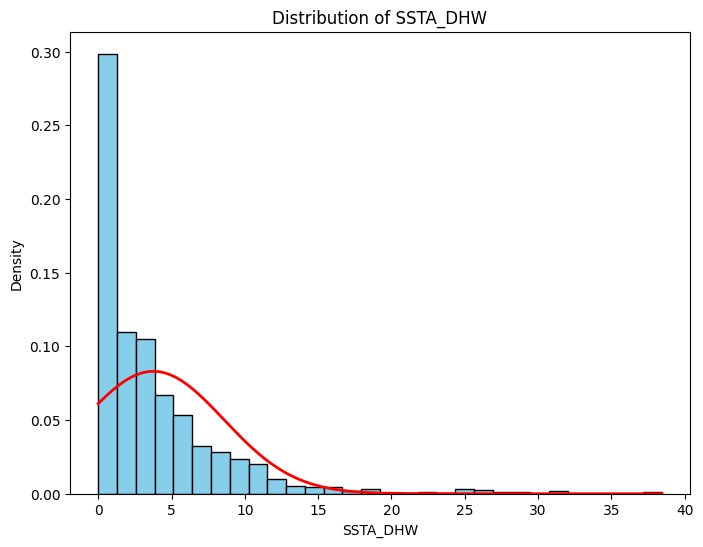

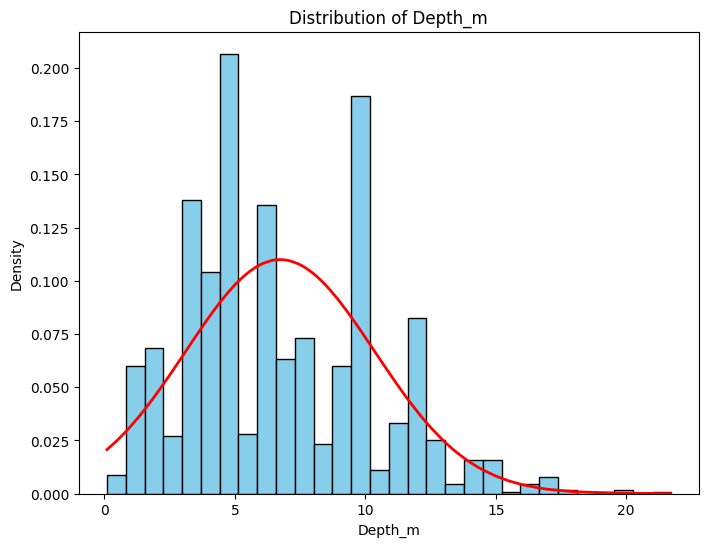

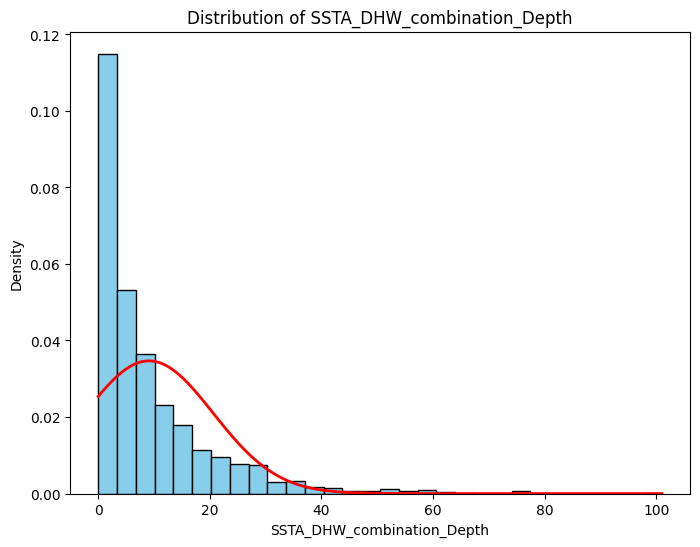

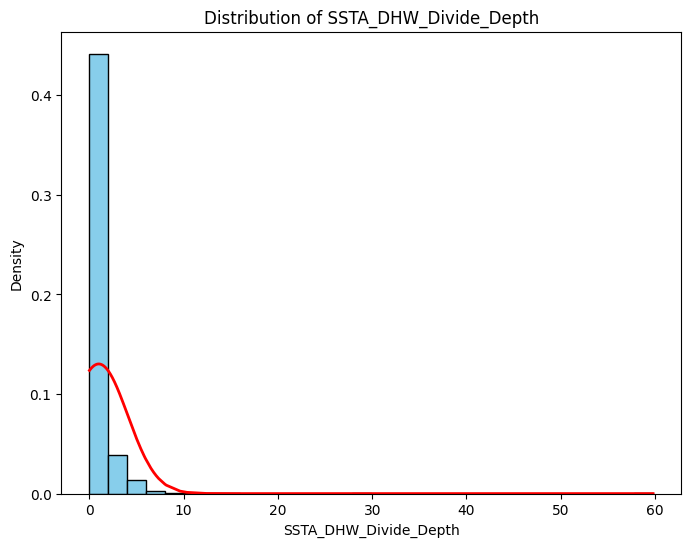

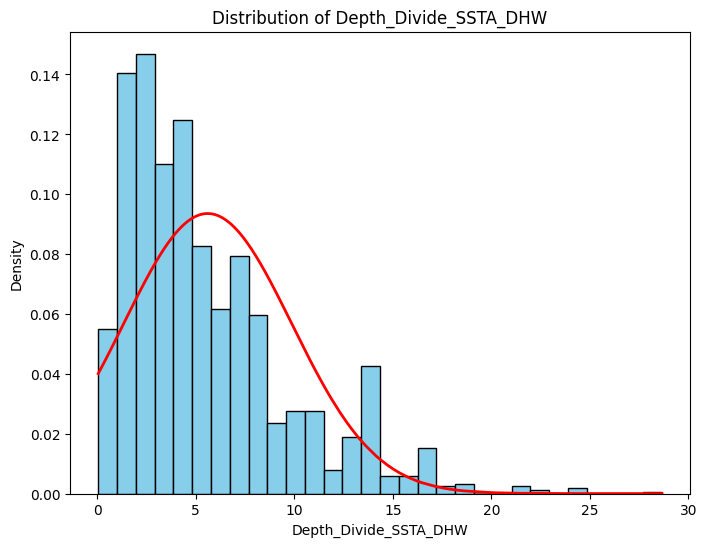

In [74]:
for i in col_needcheck:
    plotting_distribution(df_discover_feature , df_discover_feature[[i]])